In [4]:
# Check that your project files are there
import os
from pathlib import Path

# Set project root manually
project_root = Path(r"D:\aws-kpi-anomaly-detection")

os.chdir(project_root)

print("Current working directory:")
print(Path.cwd())

Current working directory:
D:\aws-kpi-anomaly-detection


In [6]:
import os

project_files = [
    "data/synthetic_telecom_kpi_data.csv",
    "data/sagemaker_test_features.csv",
    "data/sagemaker_test_labels.csv",
    "data/sagemaker_test_metadata.csv",
    "outputs/final_isolation_forest_model.joblib",
    "outputs/standard_scaler.joblib"
]

for file in project_files:
    print(file, "✅ Found" if os.path.exists(file) else "❌ Missing")

data/synthetic_telecom_kpi_data.csv ✅ Found
data/sagemaker_test_features.csv ✅ Found
data/sagemaker_test_labels.csv ✅ Found
data/sagemaker_test_metadata.csv ✅ Found
outputs/final_isolation_forest_model.joblib ✅ Found
outputs/standard_scaler.joblib ✅ Found


In [10]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

model = joblib.load("outputs/final_isolation_forest_model.joblib")
scaler = joblib.load("outputs/standard_scaler.joblib")

# Important: SageMaker-ready feature files were saved without headers
X_test = pd.read_csv("data/sagemaker_test_features.csv", header=None)

# Add clean feature names
X_test.columns = [f"feature_{i+1}" for i in range(X_test.shape[1])]

test_labels = pd.read_csv("data/sagemaker_test_labels.csv")
test_metadata = pd.read_csv("data/sagemaker_test_metadata.csv")

print("X_test shape:", X_test.shape)
print("Labels shape:", test_labels.shape)
print("Metadata shape:", test_metadata.shape)

print("\nTest feature columns:")
print(X_test.columns.tolist())

print("\nLabel columns:")
print(test_labels.columns.tolist())

print("\nFirst 5 rows of X_test:")
display(X_test.head())

X_test shape: (3456, 9)
Labels shape: (3456, 2)
Metadata shape: (3456, 13)

Test feature columns:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']

Label columns:
['anomaly_label', 'anomaly_type']

First 5 rows of X_test:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9
0,1.095872,1.292599,-0.880872,1.420146,-1.441102,-1.343286,-1.661325,0.0,-0.632456
1,0.744832,0.901946,-1.333165,1.207925,-1.058736,-0.886679,-1.661325,0.0,-0.632456
2,0.603093,0.571786,-0.735807,1.254473,-0.795315,-0.808521,-1.661325,0.0,-0.632456
3,0.611628,0.269257,-0.844182,1.610070,-1.559359,-0.970522,-1.661325,0.0,-0.632456
4,0.510252,0.897862,-0.740714,1.374181,-1.260125,-1.932891,-1.661325,0.0,-0.632456


In [12]:
label_col = "anomaly_label"

y_true = test_labels[label_col].astype(int).values

print("Using label column:", label_col)
print("Number of test samples:", len(y_true))
print("Number of true anomalies:", y_true.sum())
print("Anomaly percentage:", round(y_true.mean() * 100, 2), "%")

assert len(X_test) == len(y_true) == len(test_metadata), "Mismatch between features, labels, and metadata"

Using label column: anomaly_label
Number of test samples: 3456
Number of true anomalies: 80
Anomaly percentage: 2.31 %


In [14]:
# The SageMaker test features are already scaled/prepared
X_test_scaled = X_test.values

raw_predictions = model.predict(X_test_scaled)

# Isolation Forest returns:
#  1 = normal
# -1 = anomaly
y_pred = np.where(raw_predictions == -1, 1, 0)

# Higher score = more anomalous
anomaly_scores = -model.decision_function(X_test_scaled)

print("Predicted anomalies:", y_pred.sum())
print("Predicted anomaly percentage:", round(y_pred.mean() * 100, 2), "%")
print("Score range:", anomaly_scores.min(), "to", anomaly_scores.max())

Predicted anomalies: 80
Predicted anomaly percentage: 2.31 %
Score range: -0.14827610315260215 to 0.10581394927506615


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print("Isolation Forest Evaluation")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

Isolation Forest Evaluation
Precision: 0.8125
Recall: 0.8125
F1-score: 0.8125

Confusion Matrix:
[[3361   15]
 [  15   65]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3376
           1       0.81      0.81      0.81        80

    accuracy                           0.99      3456
   macro avg       0.90      0.90      0.90      3456
weighted avg       0.99      0.99      0.99      3456



In [18]:
import os

os.makedirs("outputs", exist_ok=True)

final_results = test_metadata.copy()

final_results["true_anomaly"] = y_true
final_results["predicted_anomaly"] = y_pred
final_results["anomaly_score"] = anomaly_scores

final_results.to_csv("outputs/final_scored_kpi_data.csv", index=False)

print("Saved:")
print("outputs/final_scored_kpi_data.csv")

display(final_results.head())

Saved:
outputs/final_scored_kpi_data.csv


,timestamp,cell_id,rrc_setup_success_rate,handover_success_rate,call_drop_rate,throughput_mbps,prb_utilization,latency_ms,hour,day_of_week,is_weekend,anomaly_label,anomaly_type,true_anomaly,predicted_anomaly,anomaly_score
0,2026-02-12 00:00:00,CELL_001,99.587747,99.086312,0.433327,86.403462,23.854019,19.757601,0,3,0,0,normal,0,0,-0.081887
1,2026-02-12 00:00:00,CELL_002,99.315344,98.676269,0.205007,82.915192,31.162392,24.843160,0,3,0,0,normal,0,0,-0.102776
2,2026-02-12 00:00:00,CELL_003,99.205358,98.329722,0.506556,83.680302,36.197306,25.713661,0,3,0,0,normal,0,0,-0.113394
3,2026-02-12 00:00:00,CELL_004,99.211981,98.012178,0.451848,89.525246,21.593695,23.909342,0,3,0,0,normal,0,0,-0.080672
4,2026-02-12 00:00:00,CELL_005,99.133314,98.671983,0.504079,85.647949,27.313130,13.190757,0,3,0,0,normal,0,0,-0.070035


In [20]:
metrics_df = pd.DataFrame([
    {
        "project": "AWS-Based Time-Series Anomaly Detection Pipeline for Operational Intelligence",
        "use_case": "Telecom KPI anomaly detection",
        "model": "Isolation Forest",
        "contamination": 0.025,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "test_samples": len(y_true),
        "true_anomalies": int(y_true.sum()),
        "predicted_anomalies": int(y_pred.sum()),
        "true_anomaly_rate_percent": y_true.mean() * 100,
        "predicted_anomaly_rate_percent": y_pred.mean() * 100
    }
])

metrics_df.to_csv("outputs/isolation_forest_evaluation_metrics.csv", index=False)

print("Saved:")
print("outputs/isolation_forest_evaluation_metrics.csv")

display(metrics_df)

Saved:
outputs/isolation_forest_evaluation_metrics.csv


,project,use_case,model,contamination,precision,recall,f1_score,test_samples,true_anomalies,predicted_anomalies,true_anomaly_rate_percent,predicted_anomaly_rate_percent
0,AWS-Based Time-Series Anomaly Detection Pipeli...,Telecom KPI anomaly detection,Isolation Forest,0.025,0.8125,0.8125,0.8125,3456,80,80,2.314815,2.314815


In [22]:
cm_df = pd.DataFrame(
    cm,
    columns=["predicted_normal", "predicted_anomaly"],
    index=["true_normal", "true_anomaly"]
)

cm_df.to_csv("outputs/confusion_matrix.csv")

print("Saved:")
print("outputs/confusion_matrix.csv")

display(cm_df)

Saved:
outputs/confusion_matrix.csv


,predicted_normal,predicted_anomaly
true_normal,3361,15
true_anomaly,15,65


In [24]:
top_anomalies = final_results.sort_values(
    by="anomaly_score",
    ascending=False
).head(50)

top_anomalies.to_csv("outputs/top_50_anomalies.csv", index=False)

print("Saved:")
print("outputs/top_50_anomalies.csv")

display(top_anomalies.head(10))

Saved:
outputs/top_50_anomalies.csv


,timestamp,cell_id,rrc_setup_success_rate,handover_success_rate,call_drop_rate,throughput_mbps,prb_utilization,latency_ms,hour,day_of_week,is_weekend,anomaly_label,anomaly_type,true_anomaly,predicted_anomaly,anomaly_score
2009,2026-02-22 11:00:00,CELL_002,98.519927,97.805281,4.326551,21.751990,100.000000,77.610260,11,6,1,1,congestion,1,1,0.105814
2025,2026-02-22 13:00:00,CELL_002,99.081019,97.155691,4.187993,25.131309,90.137443,74.533731,13,6,1,1,congestion,1,1,0.097120
2981,2026-02-27 12:00:00,CELL_006,97.779046,96.597226,4.091405,19.885617,100.000000,80.384385,12,4,0,1,congestion,1,1,0.094864
2989,2026-02-27 13:00:00,CELL_006,97.897731,96.809983,3.959944,19.010257,100.000000,82.076711,13,4,0,1,congestion,1,1,0.092655
3013,2026-02-27 16:00:00,CELL_006,97.703006,97.361892,3.751276,22.301690,99.135382,80.256822,16,4,0,1,congestion,1,1,0.090600
2041,2026-02-22 15:00:00,CELL_002,98.246963,97.961860,4.202304,36.672947,93.145184,71.856165,15,6,1,1,congestion,1,1,0.089604
1993,2026-02-22 09:00:00,CELL_002,98.835991,97.292135,4.170077,30.117820,90.374718,73.458842,9,6,1,1,congestion,1,1,0.088680
2033,2026-02-22 14:00:00,CELL_002,98.449029,97.977263,4.191417,31.888100,97.135466,71.669096,14,6,1,1,congestion,1,1,0.087931
2997,2026-02-27 14:00:00,CELL_006,97.706906,96.838935,3.848816,18.432554,100.000000,79.696766,14,4,0,1,congestion,1,1,0.087168
1985,2026-02-22 08:00:00,CELL_002,98.942568,98.304705,3.858422,32.684998,76.975515,70.829514,8,6,1,1,congestion,1,1,0.084022


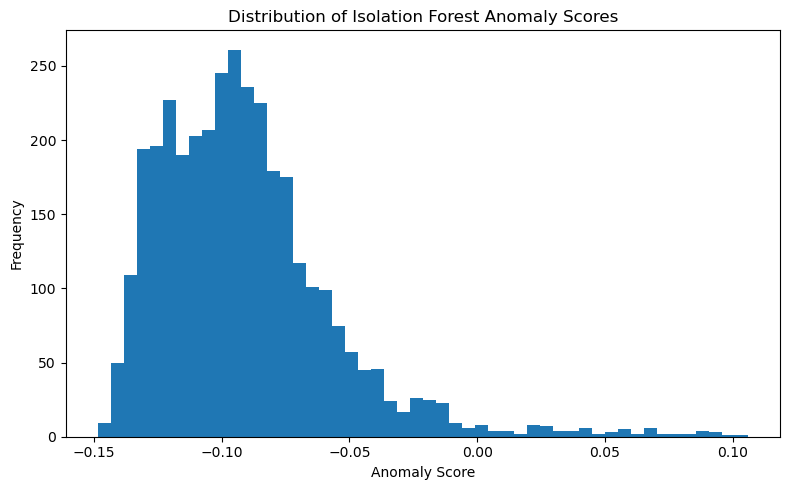

Saved:
diagrams/anomaly_score_distribution.png


In [26]:
import matplotlib.pyplot as plt

os.makedirs("diagrams", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.hist(anomaly_scores, bins=50)
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.tight_layout()
plt.savefig("diagrams/anomaly_score_distribution.png", dpi=300)
plt.show()

print("Saved:")
print("diagrams/anomaly_score_distribution.png")

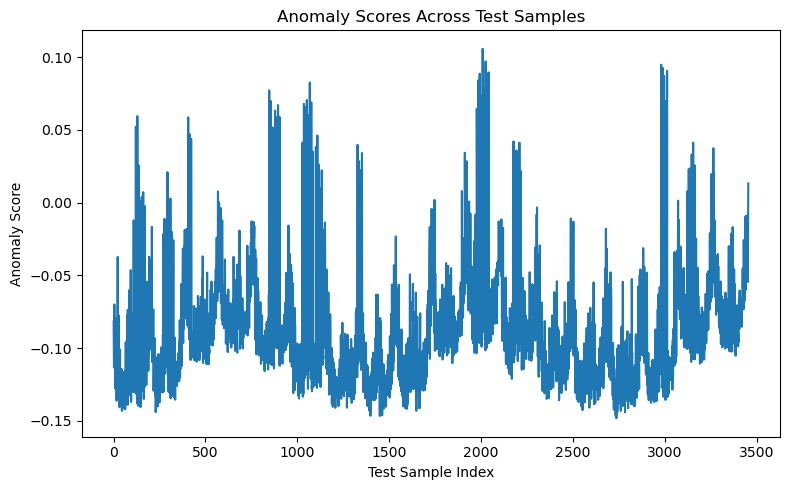

Saved:
diagrams/anomaly_scores_over_time.png


In [28]:
plt.figure(figsize=(8, 5))
plt.plot(anomaly_scores)
plt.xlabel("Test Sample Index")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Scores Across Test Samples")
plt.tight_layout()
plt.savefig("diagrams/anomaly_scores_over_time.png", dpi=300)
plt.show()

print("Saved:")
print("diagrams/anomaly_scores_over_time.png")

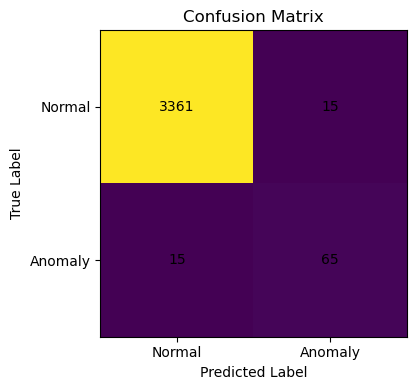

Saved:
diagrams/confusion_matrix.png


In [30]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("diagrams/confusion_matrix.png", dpi=300)
plt.show()

print("Saved:")
print("diagrams/confusion_matrix.png")

In [32]:
summary_text = f"""
AWS-Based Time-Series Anomaly Detection Pipeline for Operational Intelligence

Use case:
Telecom KPI anomaly detection

Dataset:
- Synthetic telecom KPI dataset
- Total records: 11,520
- Test records: {len(y_true)}
- True anomalies in test set: {int(y_true.sum())}
- True anomaly rate in test set: {y_true.mean() * 100:.2f}%

Local ML model:
- Isolation Forest
- Selected contamination value: 0.025

Evaluation:
- Precision: {precision:.4f}
- Recall: {recall:.4f}
- F1-score: {f1:.4f}
- Predicted anomalies: {int(y_pred.sum())}
- Predicted anomaly rate: {y_pred.mean() * 100:.2f}%

AWS cloud component:
- Amazon S3 bucket created: masood-kpi-anomaly-detection-2026
- Raw and processed data uploaded to S3
- Amazon SageMaker Random Cut Forest training completed successfully
- SageMaker model artifact stored in S3:
  s3://masood-kpi-anomaly-detection-2026/models/rcf/randomcutforest-2026-05-19-10-02-30-019/output/model.tar.gz

Cloud deployment note:
Batch Transform inference was planned but not executed because the AWS account-level quota for ml.m5.large transform job usage was 0 and the quota increase request was not approved at this stage.
"""

with open("outputs/project_summary.txt", "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:")
print("outputs/project_summary.txt")


AWS-Based Time-Series Anomaly Detection Pipeline for Operational Intelligence

Use case:
Telecom KPI anomaly detection

Dataset:
- Synthetic telecom KPI dataset
- Total records: 11,520
- Test records: 3456
- True anomalies in test set: 80
- True anomaly rate in test set: 2.31%

Local ML model:
- Isolation Forest
- Selected contamination value: 0.025

Evaluation:
- Precision: 0.8125
- Recall: 0.8125
- F1-score: 0.8125
- Predicted anomalies: 80
- Predicted anomaly rate: 2.31%

AWS cloud component:
- Amazon S3 bucket created: masood-kpi-anomaly-detection-2026
- Raw and processed data uploaded to S3
- Amazon SageMaker Random Cut Forest training completed successfully
- SageMaker model artifact stored in S3:
  s3://masood-kpi-anomaly-detection-2026/models/rcf/randomcutforest-2026-05-19-10-02-30-019/output/model.tar.gz

Cloud deployment note:
Batch Transform inference was planned but not executed because the AWS account-level quota for ml.m5.large transform job usage was 0 and the quota inc

In [34]:
final_files = [
    "outputs/final_scored_kpi_data.csv",
    "outputs/isolation_forest_evaluation_metrics.csv",
    "outputs/confusion_matrix.csv",
    "outputs/top_50_anomalies.csv",
    "outputs/project_summary.txt",
    "diagrams/anomaly_score_distribution.png",
    "diagrams/anomaly_scores_over_time.png",
    "diagrams/confusion_matrix.png"
]

for file in final_files:
    print(file, "✅ Found" if os.path.exists(file) else "❌ Missing")

outputs/final_scored_kpi_data.csv ✅ Found
outputs/isolation_forest_evaluation_metrics.csv ✅ Found
outputs/confusion_matrix.csv ✅ Found
outputs/top_50_anomalies.csv ✅ Found
outputs/project_summary.txt ✅ Found
diagrams/anomaly_score_distribution.png ✅ Found
diagrams/anomaly_scores_over_time.png ✅ Found
diagrams/confusion_matrix.png ✅ Found
